Found 14345 files belonging to 4 classes.
Found 2112 files belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of classes: 4
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/30
1794/1794 ━━━━━━━━━━━━━━━━━━━━ 386s 211ms/step - accuracy: 0.8217 - loss: 0.4605 - val_accuracy: 0.8097 - val_loss: 0.5404 - learning_rate: 1.0000e-04
Epoch 2/30
1794/1794 ━━━━━━━━━━━━━━━━━━━━ 388s 214ms/step - accuracy: 0.8846 - loss: 0.3047 - val_accuracy: 0.8187 - val_loss: 0.5169 - learning_rate: 1.0000e-04
Epoch 3/30
1794/1794 ━━━━━━━━━━━━━━━━━━━━ 460s 224ms/step - accuracy: 0.8979 - loss: 0.2692 - val_accuracy: 0.8295 - val_loss: 0.4858 - learning_rate: 1.0000e-04
Epoch 4/30
1794/1794 ━━━━━━━━━━━━━━━━━━━━ 398s 222ms/step - accuracy: 0.9076 - loss: 0.2446 - val_accuracy: 0.8338 - val_loss: 0.5289 - learning_rate: 1.0000e-04
Epoch 5/30
1794/1794 ━━━━━━━━━━━━━━━━━━━━ 424s 212ms/step - accuracy: 0.9109 - loss: 0.2369 - val_accuracy: 0.8442 - val_loss: 0.4838 - learning_rate: 1.0000e-04
Epoch 6/30
1794/1794 ━━━━━━━━━━━━━━━━━━━━ 430s 239ms/step - accuracy: 0.9164 - loss: 0.2166 - val_accuracy: 0.8272 - val_loss: 0.5446 - learning_rate: 1.0000e-04
Epoch 7/30
1794/1794 ━━━━━━━

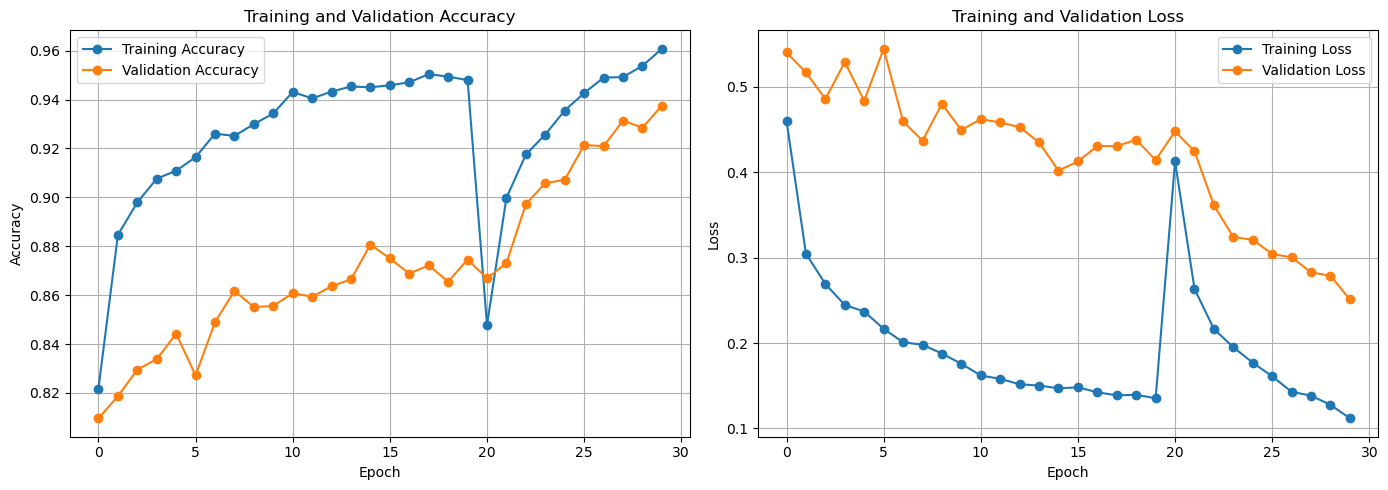

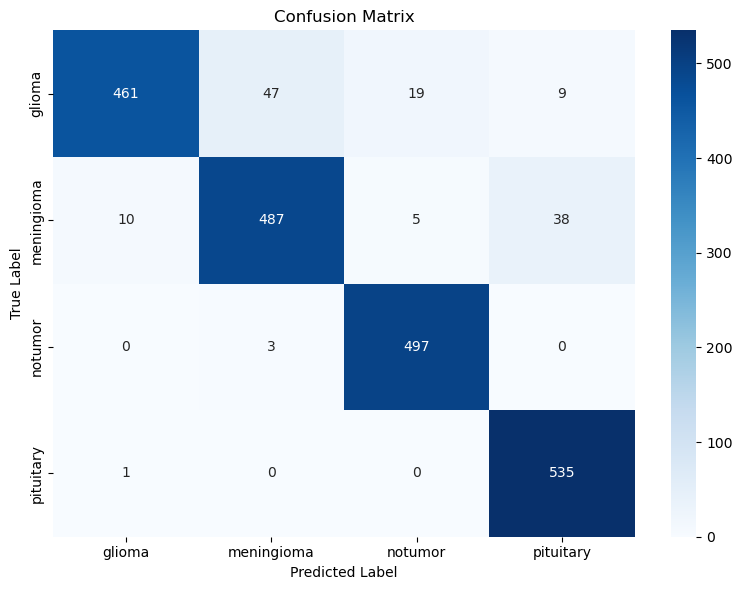


Classification Report:

              precision    recall  f1-score   support

      glioma     0.9767    0.8601    0.9147       536
  meningioma     0.9069    0.9019    0.9044       540
     notumor     0.9539    0.9940    0.9736       500
   pituitary     0.9192    0.9981    0.9571       536

    accuracy                         0.9375      2112
   macro avg     0.9392    0.9385    0.9374      2112
weighted avg     0.9389    0.9375    0.9367      2112



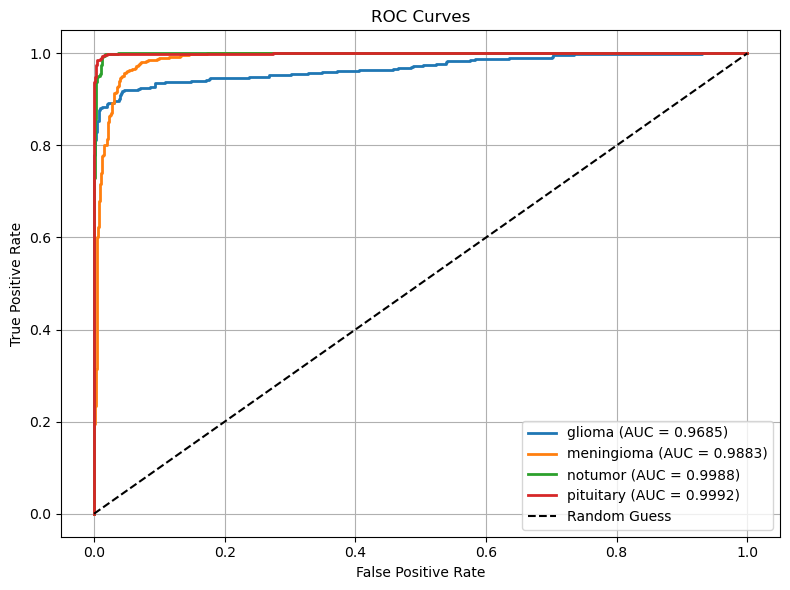

In [2]:
# ============================================================
# BRAIN TUMOR CLASSIFICATION USING MobileNetV2
# Single-cell code for Jupyter Notebook / Google Colab
#
# Outputs:
# 1. Training & Validation Accuracy Graph
# 2. Training & Validation Loss Graph
# 3. Confusion Matrix
# 4. Classification Report
# 5. ROC Curves (AUC)
# 6. Saves best and final model
# ============================================================

# Install packages if needed (uncomment if required)
# import sys
# !{sys.executable} -m pip install tensorflow matplotlib seaborn scikit-learn

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# ============================================================
# 1. DATASET PATH
# ============================================================
# Local Windows path:
DATASET_DIR = r"C:\Users\yadav\Downloads\BrainTumorProject\final_merged_dataset"

# Google Colab path:
# DATASET_DIR = "/content/drive/MyDrive/BrainTumorProject/final_merged_dataset"

TRAIN_DIR = os.path.join(DATASET_DIR, "Training")
TEST_DIR  = os.path.join(DATASET_DIR, "Testing")

# Verify paths
if not os.path.exists(TRAIN_DIR):
    raise FileNotFoundError(f"Training folder not found: {TRAIN_DIR}")

if not os.path.exists(TEST_DIR):
    raise FileNotFoundError(f"Testing folder not found: {TEST_DIR}")

# ============================================================
# 2. CONFIGURATION
# ============================================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 8
EPOCHS = 30
SEED = 42

MODEL_DIR = "mobilenetv2_output"
os.makedirs(MODEL_DIR, exist_ok=True)

# ============================================================
# 3. LOAD DATASET
# ============================================================
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

# ============================================================
# 4. OPTIMIZE DATA PIPELINE
# ============================================================
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

train_ds = train_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

# ============================================================
# 5. BUILD MobileNetV2 MODEL
# ============================================================
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation="relu")(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ============================================================
# 6. CALLBACKS
# ============================================================
callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        verbose=1
    ),
    ModelCheckpoint(
        os.path.join(MODEL_DIR, "best_model.keras"),
        monitor="val_accuracy",
        save_best_only=True
    )
]

# ============================================================
# 7. TRAIN MODEL
# ============================================================
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# ============================================================
# 8. FINE-TUNING
# ============================================================
print("\nStarting fine-tuning...")

base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

fine_tune_epochs = 10
total_epochs = len(history.history["accuracy"]) + fine_tune_epochs

history_fine = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=total_epochs,
    initial_epoch=len(history.history["accuracy"]),
    callbacks=callbacks
)

# ============================================================
# 9. COMBINE HISTORIES
# ============================================================
acc = history.history["accuracy"] + history_fine.history["accuracy"]
val_acc = history.history["val_accuracy"] + history_fine.history["val_accuracy"]

loss = history.history["loss"] + history_fine.history["loss"]
val_loss = history.history["val_loss"] + history_fine.history["val_loss"]

# ============================================================
# 10. EVALUATE MODEL
# ============================================================
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# ============================================================
# 11. SAVE MODEL
# ============================================================
model.save(os.path.join(MODEL_DIR, "mobilenetv2_brain_tumor.keras"))
print("Model saved successfully.")

# ============================================================
# 12. TRAINING & VALIDATION GRAPHS
# ============================================================
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(acc, marker='o', label='Training Accuracy')
plt.plot(val_acc, marker='o', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(loss, marker='o', label='Training Loss')
plt.plot(val_loss, marker='o', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ============================================================
# 13. PREDICTIONS
# ============================================================
y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)
    true = np.argmax(labels.numpy(), axis=1)

    y_true.extend(true)
    y_pred.extend(preds)
    y_prob.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

# ============================================================
# 14. CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# ============================================================
# 15. CLASSIFICATION REPORT
# ============================================================
print("\nClassification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

# ============================================================
# 16. ROC CURVES
# ============================================================
y_true_bin = label_binarize(
    y_true,
    classes=list(range(num_classes))
)

plt.figure(figsize=(8, 6))

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_prob[:, i]
    )
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{class_names[i]} (AUC = {roc_auc:.4f})"
    )

# Random baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()